In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"D:\Python\Python Work\Datasets\data.csv",encoding='latin1')

##### Loaded the e-commerce dataset into Python using Pandas to begin the data analysis and preprocessing workflow.

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


##### Inspected the dataset structure to understand column names, data types, and identify potential data quality issues before analysis.

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

##### Identified missing values in the dataset to ensure accurate analysis and improve overall data quality.
##### In this dataset Description and CustomerID columns contained null values, which could impact product-level analysis,customer-level analysis.

In [6]:
df.shape

(541909, 8)

##### The dataset contains 541,909 rows and 8 columns.

In [7]:
df=df.dropna(subset=['CustomerID'])

##### The CustomerID column contained 135,080 missing values, which were removed to ensure accurate customer-level analysis and revenue insights.

In [8]:
df.duplicated().sum()

5225

In [9]:
df=df.drop_duplicates()

##### The dataset contained 5,225 duplicate records, which were removed to improve data quality, avoid inaccurate calculations, and prevent duplicate transactions from affecting business insights.

In [10]:
df.shape

(401604, 8)

##### After removing duplicate records, the dataset contained a total of 401,604 records.

In [11]:
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]

##### Invoice numbers starting with the letter ‘C’ represented cancelled transactions. These records were removed to ensure accurate sales and revenue analysis by considering only successful transactions.

In [12]:
df=df[df['Quantity']>0]

##### Filtered out negative quantity values because they represent returns or invalid transactions that could distort sales analysis.

In [13]:
df=df[df['UnitPrice']>0]

##### Removed records with negative or zero unit prices to maintain accurate revenue and profitability calculations.

In [14]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

##### Converted the InvoiceDate column into datetime format to enable time-series analysis and trend-based insights.

In [15]:
df['CustomerID']=df['CustomerID'].astype(str)

##### Converted the CustomerID column into string datatype to treat customer identifiers as categorical values rather than numerical data.

In [16]:
df['TotalSales']=df['Quantity']*df['UnitPrice']

##### Created a TotalSales column to calculate revenue generated from each transaction and support KPI analysis.

In [17]:
df['Year']=df['InvoiceDate'].dt.year
df['MonthNo']=df['InvoiceDate'].dt.month
df['Month']=df['InvoiceDate'].dt.month_name()

##### Extracted Year and Month features from transaction dates to analyze seasonal sales trends and customer purchasing patterns.

In [18]:
Monthly_sales=df.groupby(['MonthNo','Month'])['TotalSales'].sum().reset_index()
print(Monthly_sales)

    MonthNo      Month   TotalSales
0         1    January   568101.310
1         2   February   446084.920
2         3      March   594081.760
3         4      April   468374.331
4         5        May   677355.150
5         6       June   660046.050
6         7       July   598962.901
7         8     August   644051.040
8         9  September   950690.202
9        10    October  1035642.450
10       11   November  1156205.610
11       12   December  1087613.170


##### Grouped the dataset by month number and month name to calculate total monthly sales and sorted the results in chronological order for better trend analysis.

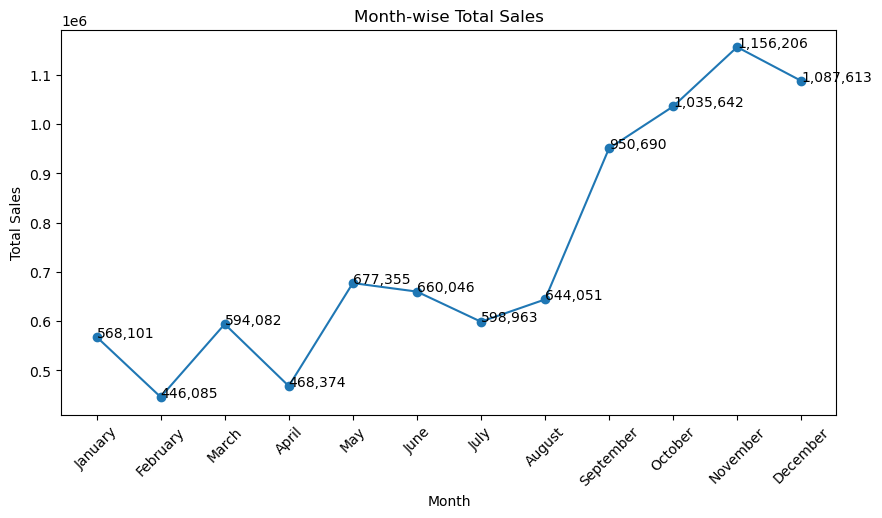

In [19]:
plt.figure(figsize=(10,5))
plt.plot(Monthly_sales['Month'],Monthly_sales['TotalSales'],marker='o')
for i,value in enumerate(Monthly_sales['TotalSales']):
    plt.text(i,value,f'{value:,.0f}')

plt.title('Month-wise Total Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [20]:
top_10con=df[df['Country']!='United Kingdom'].groupby('Country')['TotalSales'].sum().sort_values(ascending=False).reset_index().head(10)
print(top_10con)

       Country  TotalSales
0  Netherlands   285446.34
1         EIRE   265262.46
2      Germany   228678.40
3       France   208934.31
4    Australia   138453.81
5        Spain    61558.56
6  Switzerland    56443.95
7      Belgium    41196.34
8       Sweden    38367.83
9        Japan    37416.37


##### Analyzed sales by country (excluding the United Kingdom) to identify the countries generating the highest revenue. The United Kingdom contributed the highest share of overall revenue.

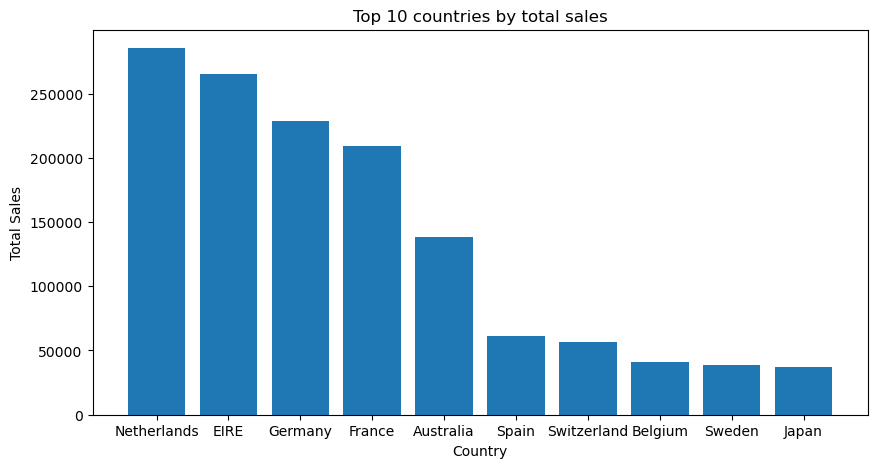

In [21]:
plt.figure(figsize=(10,5))
plt.bar(top_10con['Country'],top_10con['TotalSales'])

plt.title('Top 10 countries by total sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')

plt.show()

In [22]:
top_product=df.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).reset_index().head(10)
print(top_product)

                          Description  TotalSales
0         PAPER CRAFT , LITTLE BIRDIE   168469.60
1            REGENCY CAKESTAND 3 TIER   142264.75
2  WHITE HANGING HEART T-LIGHT HOLDER   100392.10
3             JUMBO BAG RED RETROSPOT    85040.54
4      MEDIUM CERAMIC TOP STORAGE JAR    81416.73
5                             POSTAGE    77803.96
6                       PARTY BUNTING    68785.23
7       ASSORTED COLOUR BIRD ORNAMENT    56413.03
8                              Manual    53419.93
9                  RABBIT NIGHT LIGHT    51251.24


##### Identified the highest revenue-generating products to understand customer demand and product performance.

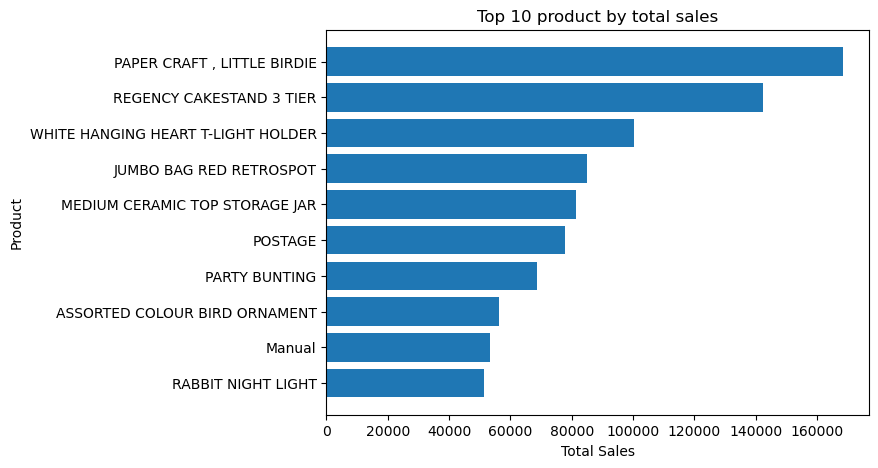

In [23]:
plt.figure(figsize=(7,5))
plt.barh(top_product['Description'],top_product['TotalSales'])
plt.gca().invert_yaxis()
plt.title('Top 10 product by total sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.show()

In [24]:
top_cust=df.groupby('CustomerID')['TotalSales'].sum().sort_values(ascending=False).reset_index().head(10)
print(top_cust)

  CustomerID  TotalSales
0    14646.0   280206.02
1    18102.0   259657.30
2    17450.0   194390.79
3    16446.0   168472.50
4    14911.0   143711.17
5    12415.0   124914.53
6    14156.0   117210.08
7    17511.0    91062.38
8    16029.0    80850.84
9    12346.0    77183.60


##### Performed customer-level revenue analysis to identify high-value customers and understand purchasing behavior.

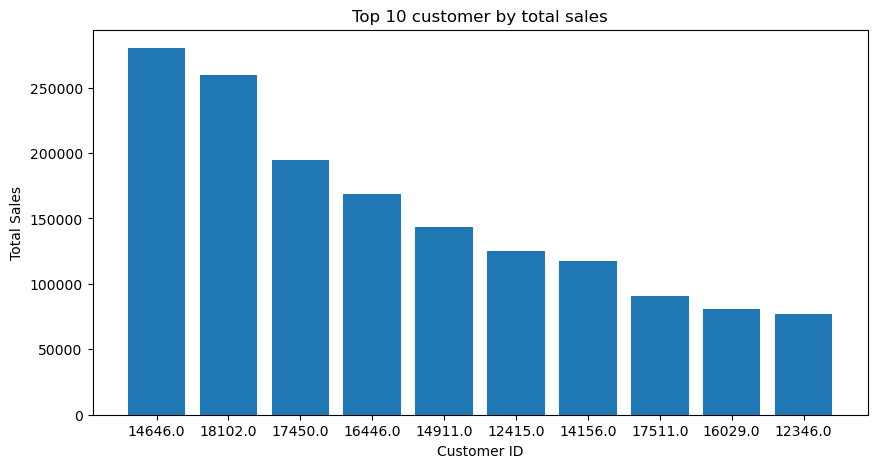

In [25]:
plt.figure(figsize=(10,5))
plt.bar(top_cust['CustomerID'],top_cust['TotalSales'])
plt.title('Top 10 customer by total sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.show()


In [ ]:
df.to_csv('Cleaned E-Commerse Data.csv',index=False)

In [ ]:
import os
print(os.getcwd())